In [1]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
from rapidfuzz import fuzz

In [2]:
# =========================
# PATHS
# =========================
PROJECT_ROOT = Path("..")
RESULTS_DIR = PROJECT_ROOT / "results"


GT_FILES = [
    Path("../data/train.json"),
    Path("../data/val.json"),
    Path("../data/test.json"),
]

METHOD_FILES = {
    "regex_tesseract": RESULTS_DIR / "regex_tesseract_160.json",
    "tesseract_llm_p1": RESULTS_DIR / "tesseract_llm_160.json",
    "tesseract_llm_p2": RESULTS_DIR / "tesseract_llm_160_prompt2.json",
    "paddle_llm_p2": RESULTS_DIR / "paddle_llm_160_prompt2.json",
    "easyocr_llm_p2": RESULTS_DIR / "easyocr_llm_160_prompt2.json",
    "doctr_llm_p2": RESULTS_DIR / "doctr_llm_160_prompt2.json",
    "openocr_llm_p2": RESULTS_DIR / "openocr_llm_160_prompt2.json",
}

FIELDS = [
    "load_number",
    "pickup_location",
    "pickup_time",
    "dropoff_location",
    "dropoff_time",
    "total_rate",
    "rate_per_mile",
]

In [3]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def normalize(x):
    if x is None:
        return ""
    x = str(x).strip().lower()
    x = " ".join(x.split())
    return x

In [4]:
ground_truth = {}

for gt_file in GT_FILES:
    data = load_json(gt_file)
    print(gt_file.name, len(data))

    for item in data:
        ground_truth[item["source_image"]] = {
            f: normalize(item.get(f, ""))
            for f in FIELDS
        }

print("Total GT:", len(ground_truth))

train.json 120
val.json 16
test.json 24
Total GT: 160


In [5]:
def align_predictions(method_path):
    data = load_json(method_path)

    pred_map = {
        item["source_image"]: item
        for item in data
    }

    aligned = []

    for img in ground_truth.keys():
        pred_item = pred_map.get(img, {})

        aligned.append({
            "gt": ground_truth[img],
            "pred": {
                f: normalize(pred_item.get(f, ""))
                for f in FIELDS
            }
        })

    return aligned

In [6]:
def exact_match(a, b):
    return int(a == b)

def fuzzy_score(a, b):
    if a == "" and b == "":
        return 1.0
    return fuzz.ratio(a, b) / 100.0

def compute_metrics(aligned_data):
    field_stats = {}

    for field in FIELDS:
        TP = FP = FN = 0
        exacts = []
        fuzzies = []
        coverage = []

        for sample in aligned_data:
            gt = sample["gt"][field]
            pred = sample["pred"][field]

            exacts.append(exact_match(gt, pred))
            fuzzies.append(fuzzy_score(gt, pred))
            coverage.append(int(pred != ""))

            if pred != "":
                if pred == gt:
                    TP += 1
                else:
                    FP += 1
            if gt != "" and pred != gt:
                FN += 1

        precision = TP / (TP + FP) if (TP + FP) else 0
        recall = TP / (TP + FN) if (TP + FN) else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

        field_stats[field] = {
            "exact": np.mean(exacts),
            "fuzzy": np.mean(fuzzies),
            "coverage": np.mean(coverage),
            "precision": precision,
            "recall": recall,
            "f1": f1,
        }

    return field_stats

In [7]:
def exact_match(a, b):
    return int(a == b)

def fuzzy_score(a, b):
    if a == "" and b == "":
        return 1.0
    return fuzz.ratio(a, b) / 100.0

def compute_metrics(aligned_data):
    field_stats = {}

    for field in FIELDS:
        TP = FP = FN = 0
        exacts = []
        fuzzies = []
        coverage = []

        for sample in aligned_data:
            gt = sample["gt"][field]
            pred = sample["pred"][field]

            exacts.append(exact_match(gt, pred))
            fuzzies.append(fuzzy_score(gt, pred))
            coverage.append(int(pred != ""))

            if pred != "":
                if pred == gt:
                    TP += 1
                else:
                    FP += 1
            if gt != "" and pred != gt:
                FN += 1

        precision = TP / (TP + FP) if (TP + FP) else 0
        recall = TP / (TP + FN) if (TP + FN) else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

        field_stats[field] = {
            "exact": np.mean(exacts),
            "fuzzy": np.mean(fuzzies),
            "coverage": np.mean(coverage),
            "precision": precision,
            "recall": recall,
            "f1": f1,
        }

    return field_stats

In [8]:
all_results = {}

for name, path in METHOD_FILES.items():
    print("Evaluating:", name)

    aligned = align_predictions(path)
    stats = compute_metrics(aligned)

    all_results[name] = stats

Evaluating: regex_tesseract
Evaluating: tesseract_llm_p1
Evaluating: tesseract_llm_p2
Evaluating: paddle_llm_p2
Evaluating: easyocr_llm_p2
Evaluating: doctr_llm_p2
Evaluating: openocr_llm_p2


In [17]:
summary = []

for method, stats in all_results.items():
    avg_exact = np.mean([stats[f]["exact"] for f in FIELDS])
    avg_fuzzy = np.mean([stats[f]["fuzzy"] for f in FIELDS])
    avg_f1 = np.mean([stats[f]["f1"] for f in FIELDS])

    summary.append({
        "method": method,
        "exact": avg_exact,
        "fuzzy": avg_fuzzy,
        "f1": avg_f1,
    })


summary

[{'method': 'regex_tesseract',
  'exact': np.float64(0.3991071428571429),
  'fuzzy': np.float64(0.5685091960452849),
  'f1': np.float64(0.47628839240515364)},
 {'method': 'tesseract_llm_p1',
  'exact': np.float64(0.2392857142857143),
  'fuzzy': np.float64(0.5429139004242364),
  'f1': np.float64(0.27873605578985844)},
 {'method': 'tesseract_llm_p2',
  'exact': np.float64(0.3267857142857143),
  'fuzzy': np.float64(0.7151344561009286),
  'f1': np.float64(0.3663130523579598)},
 {'method': 'paddle_llm_p2',
  'exact': np.float64(0.5437500000000001),
  'fuzzy': np.float64(0.7551644254988793),
  'f1': np.float64(0.60233358049102)},
 {'method': 'easyocr_llm_p2',
  'exact': np.float64(0.08392857142857144),
  'fuzzy': np.float64(0.6496291611671715),
  'f1': np.float64(0.0930491598084022)},
 {'method': 'doctr_llm_p2',
  'exact': np.float64(0.37053571428571425),
  'fuzzy': np.float64(0.7416731875623512),
  'f1': np.float64(0.4105529466688637)},
 {'method': 'openocr_llm_p2',
  'exact': np.float64(0.

In [19]:
import pandas as pd

df = pd.DataFrame(summary)
df.sort_values("f1", ascending=False)

,method,exact,fuzzy,f1
3,paddle_llm_p2,0.543750,0.755164,0.602334
0,regex_tesseract,0.399107,0.568509,0.476288
5,doctr_llm_p2,0.370536,0.741673,0.410553
2,tesseract_llm_p2,0.326786,0.715134,0.366313
1,tesseract_llm_p1,0.239286,0.542914,0.278736
6,openocr_llm_p2,0.202679,0.696488,0.224419
4,easyocr_llm_p2,0.083929,0.649629,0.093049


In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert results into dataframe
rows = []

for method, stats in all_results.items():
    for field in FIELDS:
        rows.append({
            "method": method,
            "field": field,
            "exact": stats[field]["exact"],
            "fuzzy": stats[field]["fuzzy"],
            "f1": stats[field]["f1"],
        })

df_fields = pd.DataFrame(rows)

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert results into dataframe
rows = []

for method, stats in all_results.items():
    for field in FIELDS:
        rows.append({
            "method": method,
            "field": field,
            "exact": stats[field]["exact"],
            "fuzzy": stats[field]["fuzzy"],
            "f1": stats[field]["f1"],
        })

df_fields = pd.DataFrame(rows)

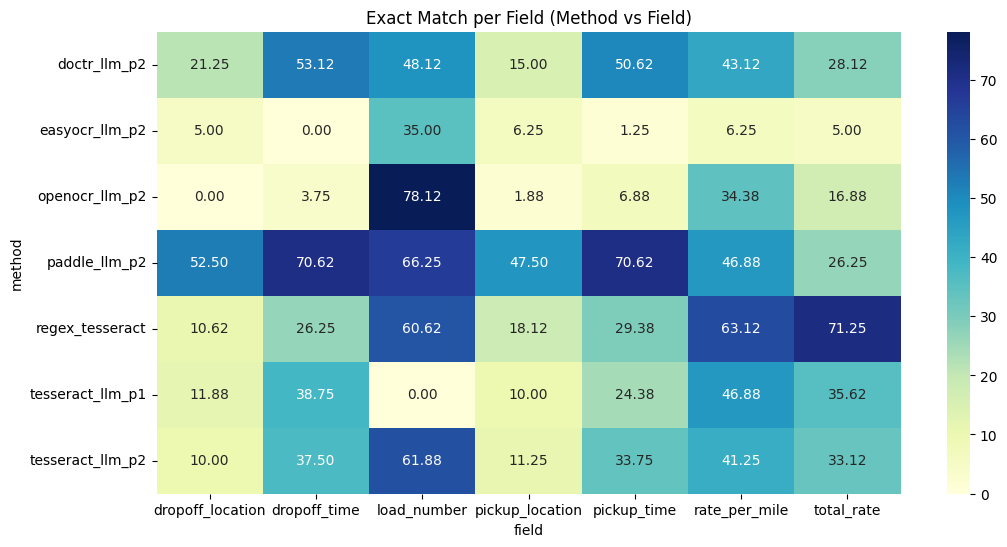

In [22]:
pivot_exact = df_fields.pivot(index="method", columns="field", values="exact")

plt.figure(figsize=(12,6))
sns.heatmap(pivot_exact *100, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Exact Match per Field (Method vs Field)")
plt.show()

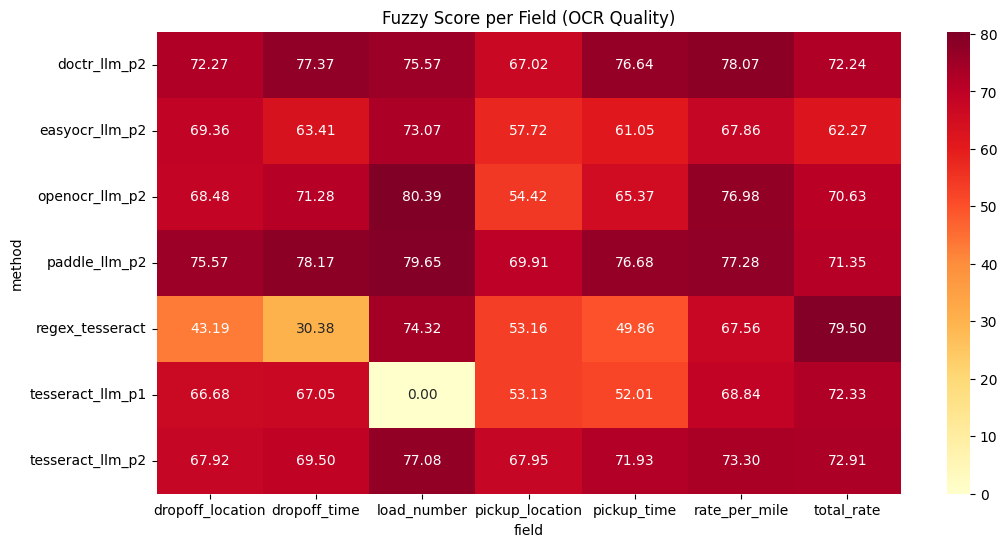

In [23]:
pivot_fuzzy = df_fields.pivot(index="method", columns="field", values="fuzzy")

plt.figure(figsize=(12,6))
sns.heatmap(pivot_fuzzy*100, annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Fuzzy Score per Field (OCR Quality)")
plt.show()

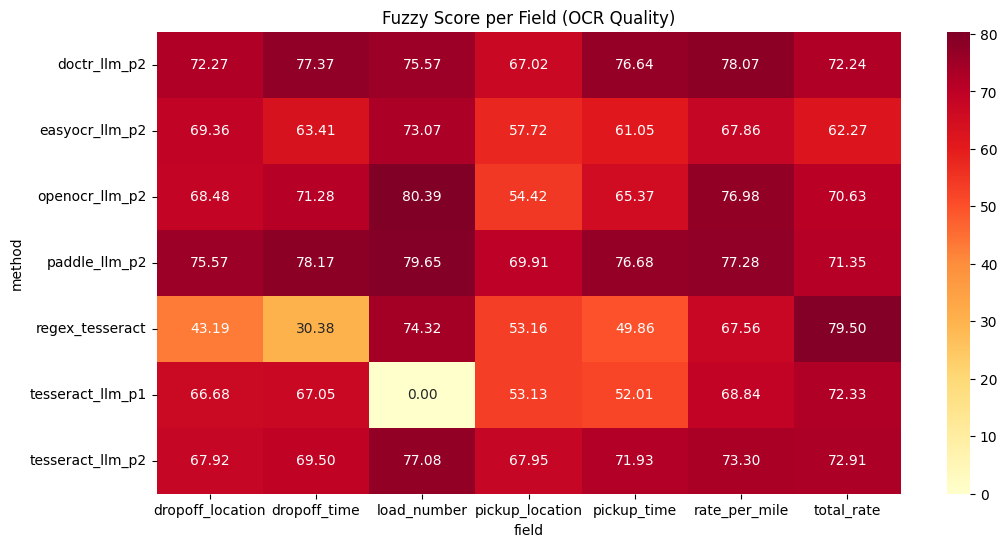

In [24]:
pivot_fuzzy = df_fields.pivot(index="method", columns="field", values="fuzzy")

plt.figure(figsize=(12,6))
sns.heatmap(pivot_fuzzy*100, annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Fuzzy Score per Field (OCR Quality)")
plt.show()

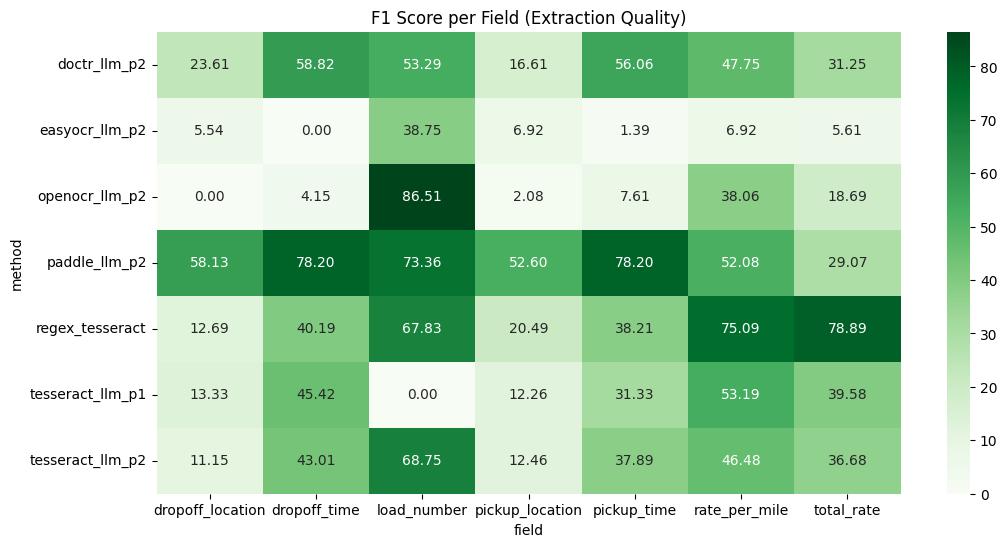

In [25]:
pivot_f1 = df_fields.pivot(index="method", columns="field", values="f1")

plt.figure(figsize=(12,6))
sns.heatmap(pivot_f1*100, annot=True, cmap="Greens", fmt=".2f")
plt.title("F1 Score per Field (Extraction Quality)")
plt.show()

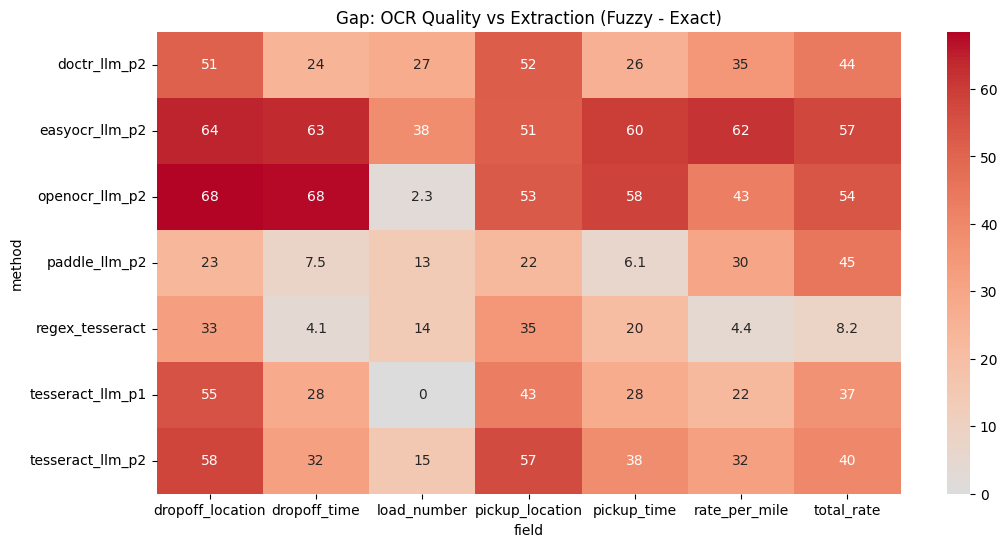

In [26]:
df_fields["gap"] = df_fields["fuzzy"] - df_fields["exact"]

pivot_gap = df_fields.pivot(index="method", columns="field", values="gap")

plt.figure(figsize=(12,6))
sns.heatmap(pivot_gap*100, annot=True, cmap="coolwarm", center=0)
plt.title("Gap: OCR Quality vs Extraction (Fuzzy - Exact)")
plt.show()